# EDA Pipeline: `grading_results_with_ta.csv`
End-to-end data analysis following the pipeline outlined in `docs/deep-research-report.md`.

**Sections**
1. Data Ingestion & Validation
2. Schema Inference & Type Validation
3. Missing Value Analysis
4. Descriptive Statistics
5. Distributions & Visualizations
6. Correlation & Multicollinearity
7. Time-Series Checks *(N/A — no datetime column)*
8. Outlier & Anomaly Detection
9. Data Quality & Cleaning
10. Feature Engineering

In [1]:
import os, ast, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.neighbors import LocalOutlierFactor
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

DATA_PATH = "consolidated_results/grading_results_with_ta.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Libraries loaded. Output dir:", OUTPUT_DIR)

Libraries loaded. Output dir: outputs


## Phase 1 — Data Ingestion & Validation

In [2]:
import csv

# --- File size ---
file_size_bytes = os.path.getsize(DATA_PATH)
print(f"File size: {file_size_bytes / 1024:.1f} KB")

# --- Delimiter & encoding sniff ---
with open(DATA_PATH, "r", encoding="utf-8") as f:
    sample = f.read(4096)
dialect = csv.Sniffer().sniff(sample)
print(f"Detected delimiter: '{dialect.delimiter}'")

# --- Load ---
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8", delimiter=dialect.delimiter)
print(f"\nShape: {df_raw.shape}  (rows × cols)")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(2)

File size: 6098.1 KB
Detected delimiter: ','

Shape: (840, 13)  (rows × cols)
Columns: ['student_id', 'model', 'run', 'total_score', 'total_points', 'feedback_by_question', 'overall_feedback', 'llm_call_time_taken', 'total_time_taken', 'ta1_total_score', 'ta2_total_score', 'ta3_total_score', 'ta_grades_by_question']


,student_id,model,run,total_score,total_points,feedback_by_question,overall_feedback,llm_call_time_taken,total_time_taken,ta1_total_score,ta2_total_score,ta3_total_score,ta_grades_by_question
0,1,gpt-5,1,80.5,133.0,"{'1': {'score': 2.5, 'max_points': 19.0, 'stre...",Strong performance on memory translation (Q6) ...,114.064339,114.066381,89.0,61.0,89.0,"{""1"": {""full_points"": 19, ""score_1"": 7.0, ""sco..."
1,1,gpt-5,2,86.0,133.0,"{'1': {'score': 4.0, 'max_points': 19.0, 'stre...",Solid performance on synchronization and addre...,116.297557,116.299043,89.0,61.0,89.0,"{""1"": {""full_points"": 19, ""score_1"": 7.0, ""sco..."


In [3]:
# --- Content validation ---
print("=== df.info() ===")
df_raw.info()

# Duplicate composite key check
dup_mask = df_raw.duplicated(subset=["student_id", "model", "run"])
print(f"\nDuplicate (student_id, model, run) rows: {dup_mask.sum()}")

# Value range checks
run_valid = df_raw["run"].isin([1, 2, 3]).all()
sid_valid = (df_raw["student_id"] > 0).all()
score_valid = (df_raw["total_score"] <= df_raw["total_points"]).all()
print(f"run ∈ {{1,2,3}}: {run_valid}")
print(f"student_id > 0: {sid_valid}")
print(f"total_score ≤ total_points: {score_valid}")

# total_points constant?
print(f"total_points unique values: {df_raw['total_points'].unique()}")

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             840 non-null    int64  
 1   model                  840 non-null    str    
 2   run                    840 non-null    int64  
 3   total_score            840 non-null    float64
 4   total_points           840 non-null    float64
 5   feedback_by_question   840 non-null    str    
 6   overall_feedback       818 non-null    str    
 7   llm_call_time_taken    840 non-null    float64
 8   total_time_taken       840 non-null    float64
 9   ta1_total_score        840 non-null    float64
 10  ta2_total_score        840 non-null    float64
 11  ta3_total_score        840 non-null    float64
 12  ta_grades_by_question  840 non-null    str    
dtypes: float64(7), int64(2), str(4)
memory usage: 85.4 KB

Duplicate (student_id, model, run) rows: 0
run ∈

## Phase 2 — Schema Inference & Type Validation

In [4]:
df = df_raw.copy()

# Cast identifiers to int
df["student_id"] = df["student_id"].astype(int)
df["run"] = df["run"].astype(int)

# Confirm numeric columns
numeric_cols = ["total_score", "total_points", "llm_call_time_taken", "total_time_taken",
                "ta1_total_score", "ta2_total_score", "ta3_total_score"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Dtypes after casting:")
print(df[["student_id", "run"] + numeric_cols].dtypes)

# Parse JSON-like string columns
def safe_parse(value):
    if pd.isna(value):
        return {}
    try:
        return ast.literal_eval(value)
    except Exception:
        try:
            return json.loads(value)
        except Exception:
            return {}

df["feedback_parsed"] = df["feedback_by_question"].apply(safe_parse)
df["ta_grades_parsed"] = df["ta_grades_by_question"].apply(safe_parse)
print(f"\nSample feedback keys: {list(df['feedback_parsed'].iloc[0].keys())}")
print(f"Sample ta_grades keys: {list(df['ta_grades_parsed'].iloc[0].keys())}")

Dtypes after casting:
student_id               int64
run                      int64
total_score            float64
total_points           float64
llm_call_time_taken    float64
total_time_taken       float64
ta1_total_score        float64
ta2_total_score        float64
ta3_total_score        float64
dtype: object



Sample feedback keys: ['1', '2', '3', '4', '5', '6']
Sample ta_grades keys: ['1', '2', '3', '4', '5', '6']


## Phase 3 — Missing Value Analysis

In [5]:
# Per-column null summary
null_counts = df.isnull().sum()
null_pct = df.isna().mean() * 100
missing_df = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct.round(2)})
missing_df = missing_df[missing_df["null_count"] > 0]
print("Columns with missing values:")
display(missing_df)

# Is missingness in overall_feedback correlated with model or run?
if "overall_feedback" in df.columns:
    df["feedback_missing"] = df["overall_feedback"].isna().astype(int)
    print("\nMissing overall_feedback by model:")
    display(df.groupby("model")["feedback_missing"].agg(["sum", "mean"]).rename(
        columns={"sum": "missing_count", "mean": "missing_rate"}
    ).round(3))
    print("\nMissing overall_feedback by run:")
    display(df.groupby("run")["feedback_missing"].agg(["sum", "mean"]).rename(
        columns={"sum": "missing_count", "mean": "missing_rate"}
    ).round(3))

# Check per-question TA null inside parsed JSON
ta_q_nulls = {}
for q in ["1", "2", "3", "4", "5", "6"]:
    for ta in ["score_1", "score_2", "score_3"]:
        vals = df["ta_grades_parsed"].apply(lambda d: d.get(q, {}).get(ta) if isinstance(d, dict) else None)
        nulls = vals.isna().sum()
        if nulls > 0:
            ta_q_nulls[f"Q{q}_{ta}"] = nulls
print("\nPer-question TA null counts inside JSON:", ta_q_nulls)

Columns with missing values:


,null_count,null_pct
overall_feedback,22,2.62



Missing overall_feedback by model:


,missing_count,missing_rate
model,,
gemini-2.5-flash,22,0.183
gemini-2.5-pro,0,0.000
global.anthropic.claude-haiku-4-5-20251001-v1:0,0,0.000
global.anthropic.claude-opus-4-6-v1,0,0.000
global.anthropic.claude-sonnet-4-6,0,0.000
gpt-4o,0,0.000
gpt-5,0,0.000



Missing overall_feedback by run:


,missing_count,missing_rate
run,,
1,7,0.025
2,5,0.018
3,10,0.036



Per-question TA null counts inside JSON: {'Q6_score_2': np.int64(840)}


## Phase 4 — Descriptive Statistics per Column

In [6]:
# Numeric stats
print("=== Numeric column statistics ===")
display(df[numeric_cols].describe().T.round(3))

# Mode for key numeric cols
for col in ["total_score", "run"]:
    mode_val = df[col].mode().iloc[0]
    print(f"Mode of {col}: {mode_val}")

# Categorical stats
print("\n=== Categorical column statistics ===")
display(df[["model", "overall_feedback"]].describe(include="object"))

# Model distribution
print("\nModel value counts:")
display(df["model"].value_counts())

# Run distribution
print("\nRun value counts:")
display(df["run"].value_counts().sort_index())

# Students
print(f"\nUnique students: {df['student_id'].nunique()}")

=== Numeric column statistics ===


,count,mean,std,min,25%,50%,75%,max
total_score,840.0,73.917,22.706,6.000,58.375,74.000,92.625,125.000
total_points,840.0,133.000,0.000,133.000,133.000,133.000,133.000,133.000
llm_call_time_taken,840.0,50.657,44.762,5.032,25.149,36.442,56.594,386.259
total_time_taken,840.0,50.660,44.762,5.034,25.151,36.444,56.596,386.260
ta1_total_score,840.0,81.912,16.408,42.000,74.000,82.500,95.250,114.000
ta2_total_score,840.0,55.562,13.590,22.000,44.000,57.000,63.250,81.000
ta3_total_score,840.0,81.375,19.381,35.000,71.750,85.500,94.250,115.000


Mode of total_score: 101.0
Mode of run: 1

=== Categorical column statistics ===


,model,overall_feedback
count,840,818
unique,7,818
top,gpt-5,Strong performance on memory translation (Q6) ...
freq,120,1



Model value counts:


model
gpt-5                                              120
gpt-4o                                             120
global.anthropic.claude-opus-4-6-v1                120
global.anthropic.claude-sonnet-4-6                 120
global.anthropic.claude-haiku-4-5-20251001-v1:0    120
gemini-2.5-flash                                   120
gemini-2.5-pro                                     120
Name: count, dtype: int64


Run value counts:


run
1    280
2    280
3    280
Name: count, dtype: int64


Unique students: 40


In [7]:
# Per-question AI score extraction from feedback_parsed
QUESTIONS = ["1", "2", "3", "4", "5", "6"]

for q in QUESTIONS:
    df[f"q{q}_ai_score"] = df["feedback_parsed"].apply(
        lambda d: d.get(q, {}).get("score") if isinstance(d, dict) else None
    )
    df[f"q{q}_ai_max"] = df["feedback_parsed"].apply(
        lambda d: d.get(q, {}).get("max_points") if isinstance(d, dict) else None
    )

ai_q_cols = [f"q{q}_ai_score" for q in QUESTIONS]
print("Per-question AI score means across all rows:")
display(df[ai_q_cols].describe().T.round(3))

# Per-question TA score extraction
for q in QUESTIONS:
    for ta_idx, ta_key in enumerate(["score_1", "score_2", "score_3"], start=1):
        df[f"q{q}_ta{ta_idx}_score"] = df["ta_grades_parsed"].apply(
            lambda d, _q=q, _k=ta_key: d.get(_q, {}).get(_k) if isinstance(d, dict) else None
        )

ta_q_cols = [f"q{q}_ta1_score" for q in QUESTIONS]
print("\nPer-question TA1 score means:")
display(df[ta_q_cols].describe().T.round(3))

Per-question AI score means across all rows:


,count,mean,std,min,25%,50%,75%,max
q1_ai_score,840.0,10.545,6.557,0.0,6.0,11.0,16.0,19.0
q2_ai_score,836.0,8.769,5.984,0.0,4.0,8.0,16.0,16.0
q3_ai_score,819.0,7.901,4.598,0.0,5.0,8.0,11.0,15.0
q4_ai_score,818.0,10.413,5.223,0.0,8.0,10.0,16.0,16.0
q5_ai_score,816.0,12.607,8.528,0.0,6.0,12.0,18.0,27.0
q6_ai_score,816.0,25.276,12.825,0.0,15.0,25.0,40.0,40.0



Per-question TA1 score means:


,count,mean,std,min,25%,50%,75%,max
q1_ta1_score,840.0,11.988,6.613,0.0,6.875,13.0,19.0,19.0
q2_ta1_score,840.0,10.100,5.730,0.0,4.000,10.0,16.0,16.0
q3_ta1_score,840.0,10.375,3.735,1.0,8.000,10.0,15.0,15.0
q4_ta1_score,840.0,11.150,5.060,0.0,8.000,9.0,16.0,16.0
q5_ta1_score,840.0,12.875,8.852,0.0,5.000,11.0,20.0,27.0
q6_ta1_score,840.0,25.425,11.314,0.0,24.500,30.0,35.0,40.0


## Phase 5 — Distributions & Visualizations

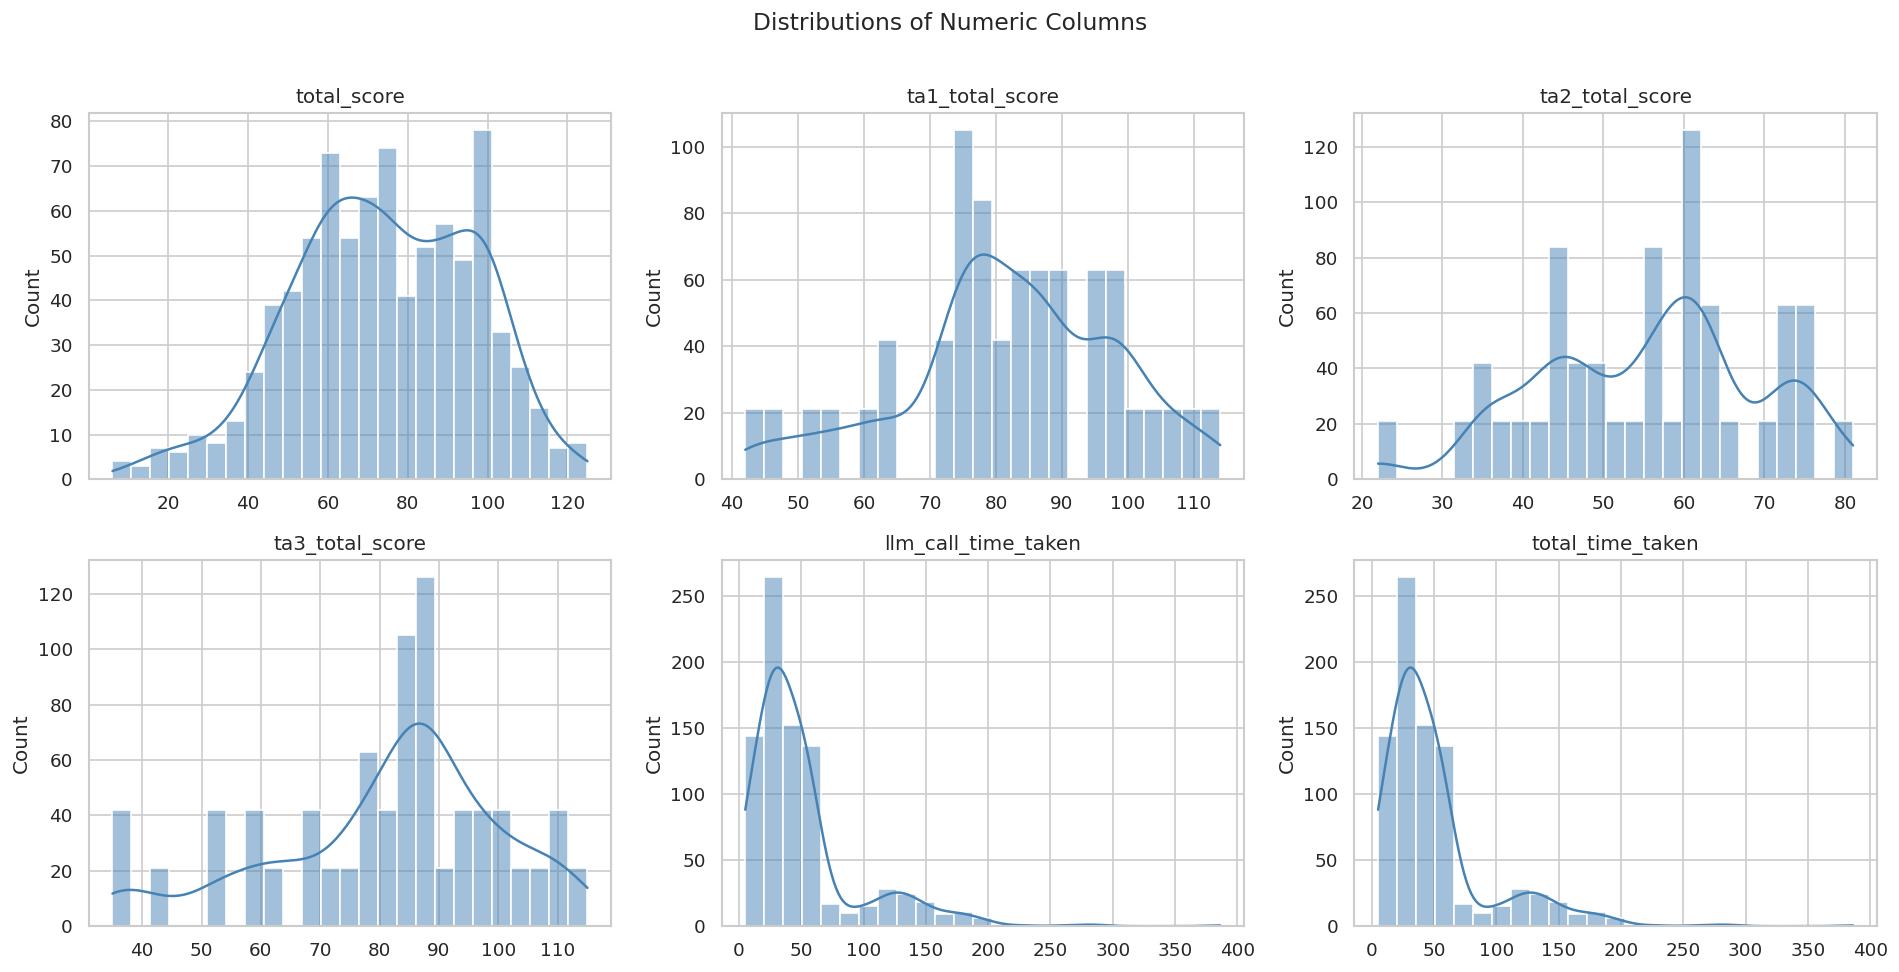

In [8]:
# 5a. Histograms for numeric columns
hist_cols = ["total_score", "ta1_total_score", "ta2_total_score", "ta3_total_score",
             "llm_call_time_taken", "total_time_taken"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, hist_cols):
    sns.histplot(df[col].dropna(), kde=True, bins=25, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distributions of Numeric Columns", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/hist_numeric.png", bbox_inches="tight")
plt.show()

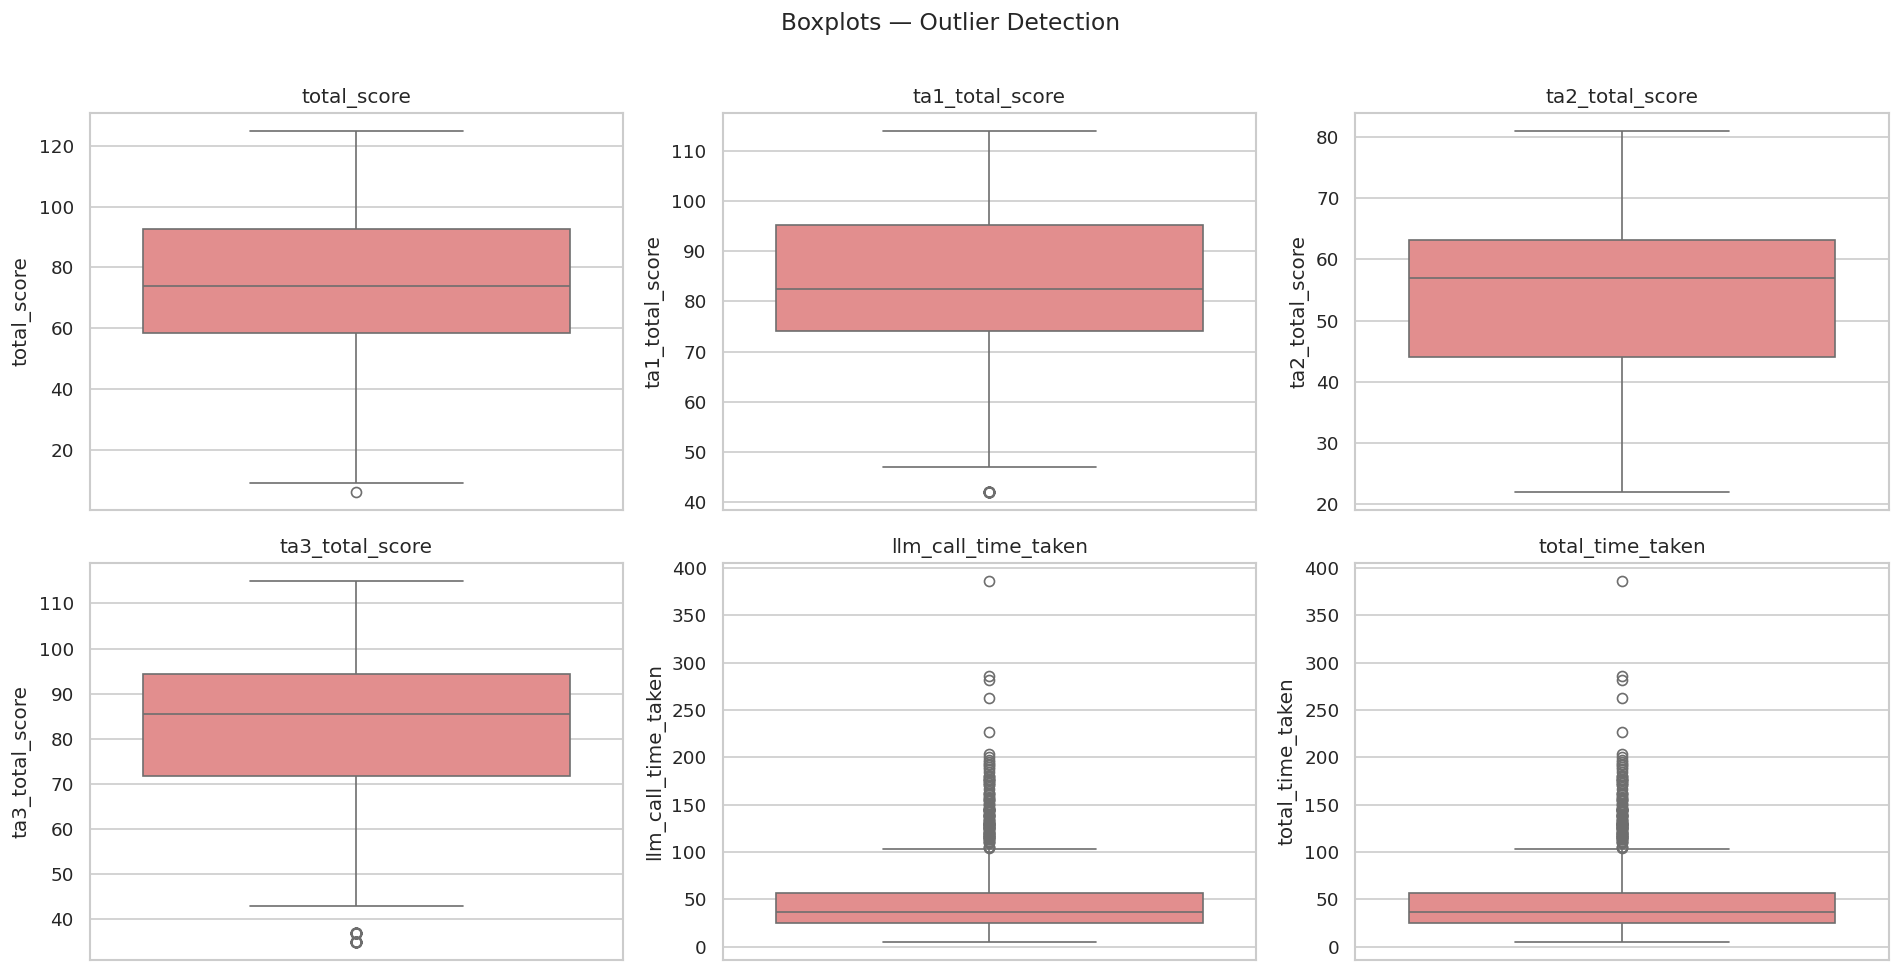

In [9]:
# 5b. Boxplots per numeric column
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, hist_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="lightcoral")
    ax.set_title(col)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/boxplots_numeric.png", bbox_inches="tight")
plt.show()

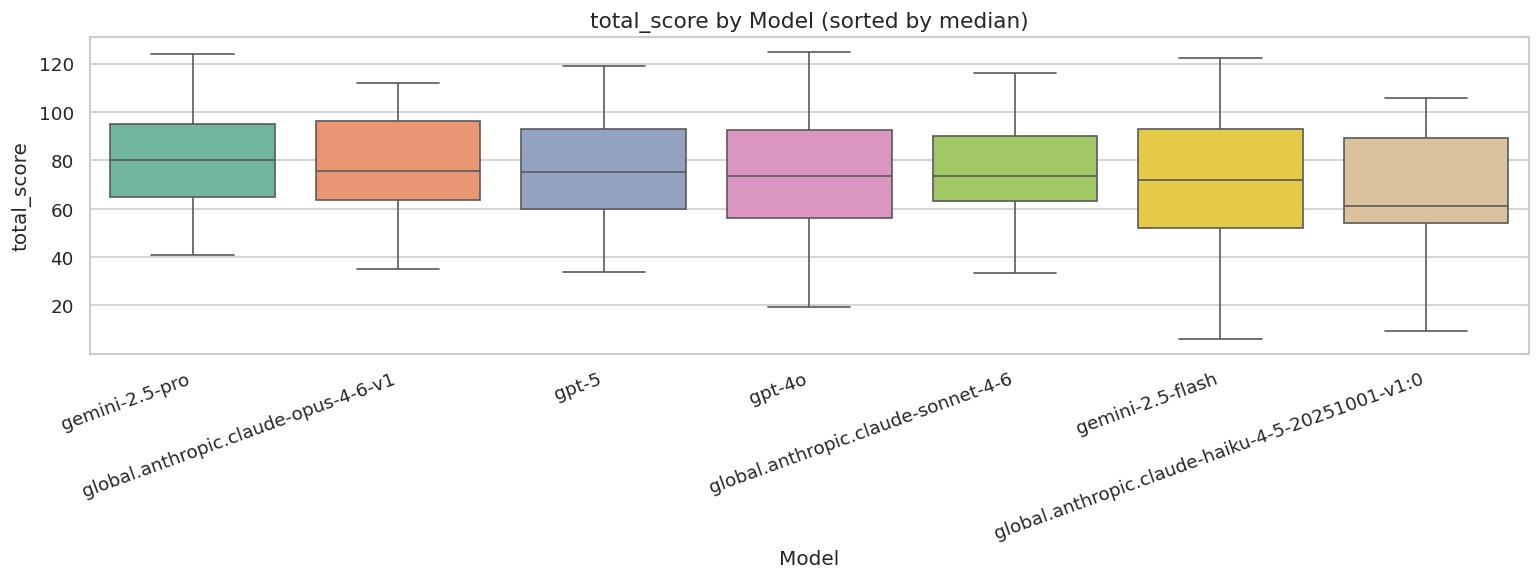

In [10]:
# 5c. total_score grouped by model (boxplot)
fig, ax = plt.subplots(figsize=(13, 5))
model_order = df.groupby("model")["total_score"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="model", y="total_score", order=model_order, ax=ax, palette="Set2")
ax.set_title("total_score by Model (sorted by median)", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("total_score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/boxplot_score_by_model.png", bbox_inches="tight")
plt.show()

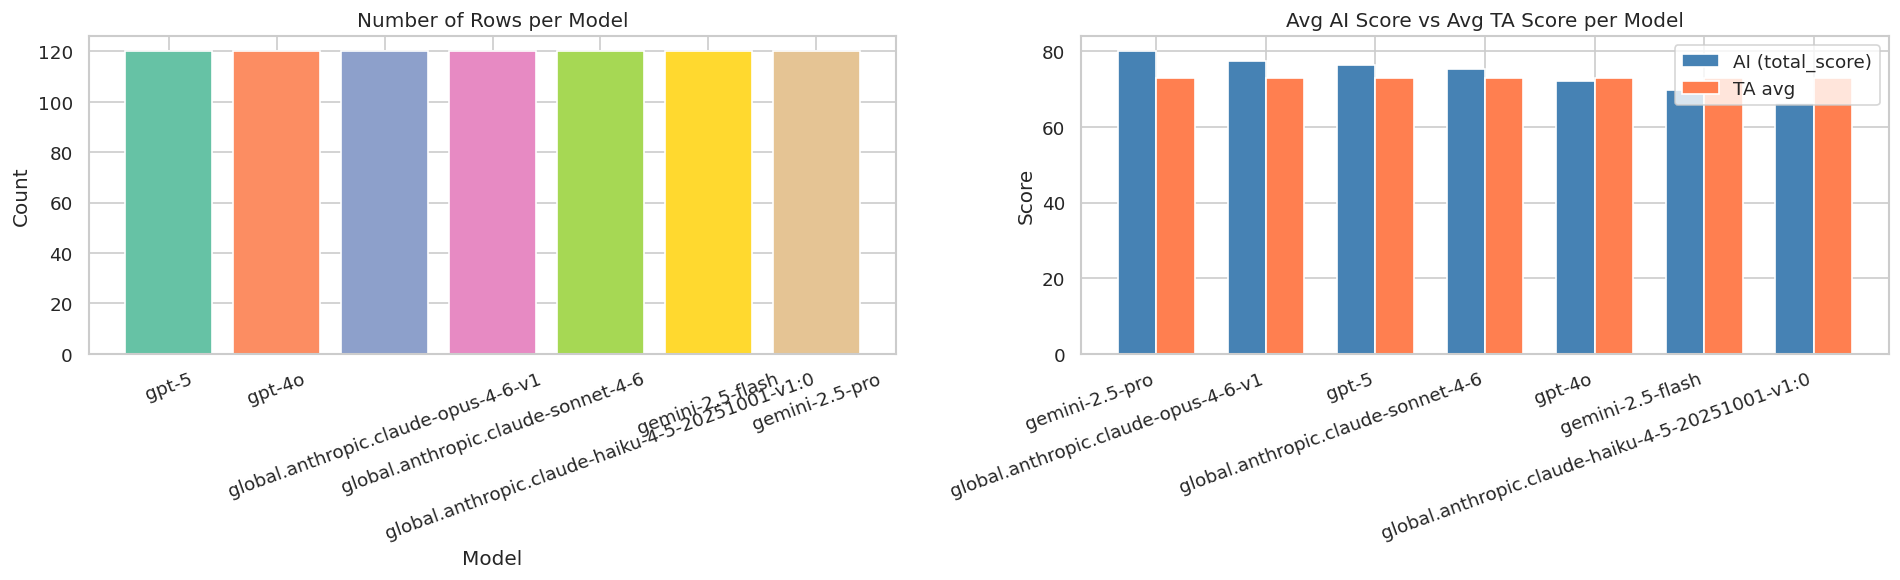

In [11]:
# 5d. Model counts bar chart + avg AI score vs avg TA score side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count
model_counts = df["model"].value_counts()
axes[0].bar(model_counts.index, model_counts.values, color=sns.color_palette("Set2", len(model_counts)))
axes[0].set_title("Number of Rows per Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

# Avg AI vs avg TA per model
ta_avg = df.groupby("model")[["ta1_total_score", "ta2_total_score", "ta3_total_score"]].mean()
ta_avg["ta_mean"] = ta_avg.mean(axis=1)
ai_avg = df.groupby("model")["total_score"].mean().rename("ai_mean")
cmp_df = pd.concat([ai_avg, ta_avg["ta_mean"]], axis=1).sort_values("ai_mean", ascending=False)
x = np.arange(len(cmp_df))
w = 0.35
axes[1].bar(x - w/2, cmp_df["ai_mean"], width=w, label="AI (total_score)", color="steelblue")
axes[1].bar(x + w/2, cmp_df["ta_mean"], width=w, label="TA avg", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cmp_df.index, rotation=20, ha="right")
axes[1].set_title("Avg AI Score vs Avg TA Score per Model")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/bar_model_comparison.png", bbox_inches="tight")
plt.show()

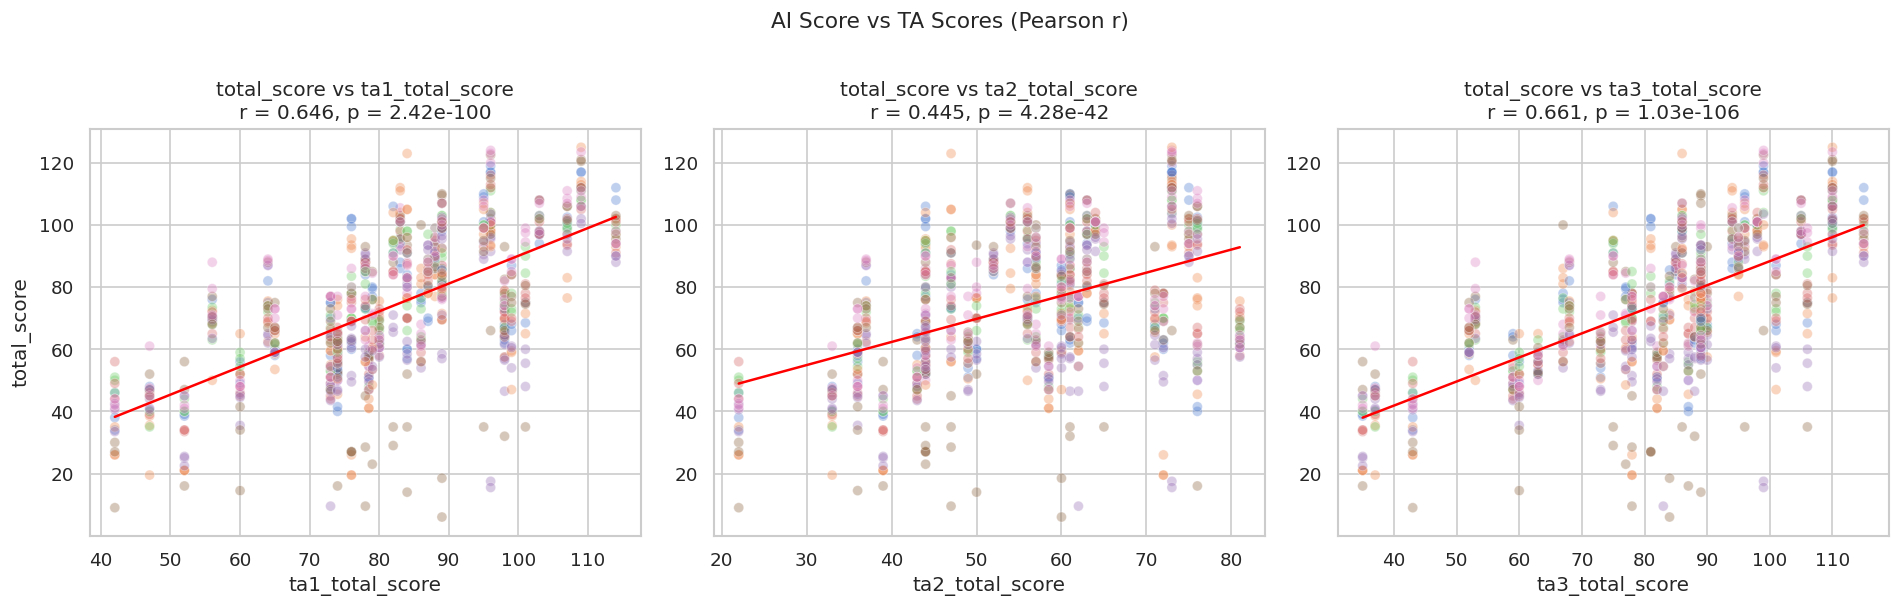

In [12]:
# 5e. Scatter: total_score vs each TA score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ta_score_cols = ["ta1_total_score", "ta2_total_score", "ta3_total_score"]
for ax, ta_col in zip(axes, ta_score_cols):
    sns.scatterplot(data=df, x=ta_col, y="total_score", alpha=0.35, ax=ax, hue="model",
                    legend=False)
    # regression line
    valid = df[[ta_col, "total_score"]].dropna()
    m, b = np.polyfit(valid[ta_col], valid["total_score"], 1)
    xr = np.linspace(valid[ta_col].min(), valid[ta_col].max(), 100)
    ax.plot(xr, m * xr + b, color="red", linewidth=1.5)
    r, p = stats.pearsonr(valid[ta_col], valid["total_score"])
    ax.set_title(f"total_score vs {ta_col}\nr = {r:.3f}, p = {p:.2e}")
    ax.set_xlabel(ta_col)
    ax.set_ylabel("total_score" if axes[0] == ax else "")
plt.suptitle("AI Score vs TA Scores (Pearson r)", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/scatter_ai_vs_ta.png", bbox_inches="tight")
plt.show()

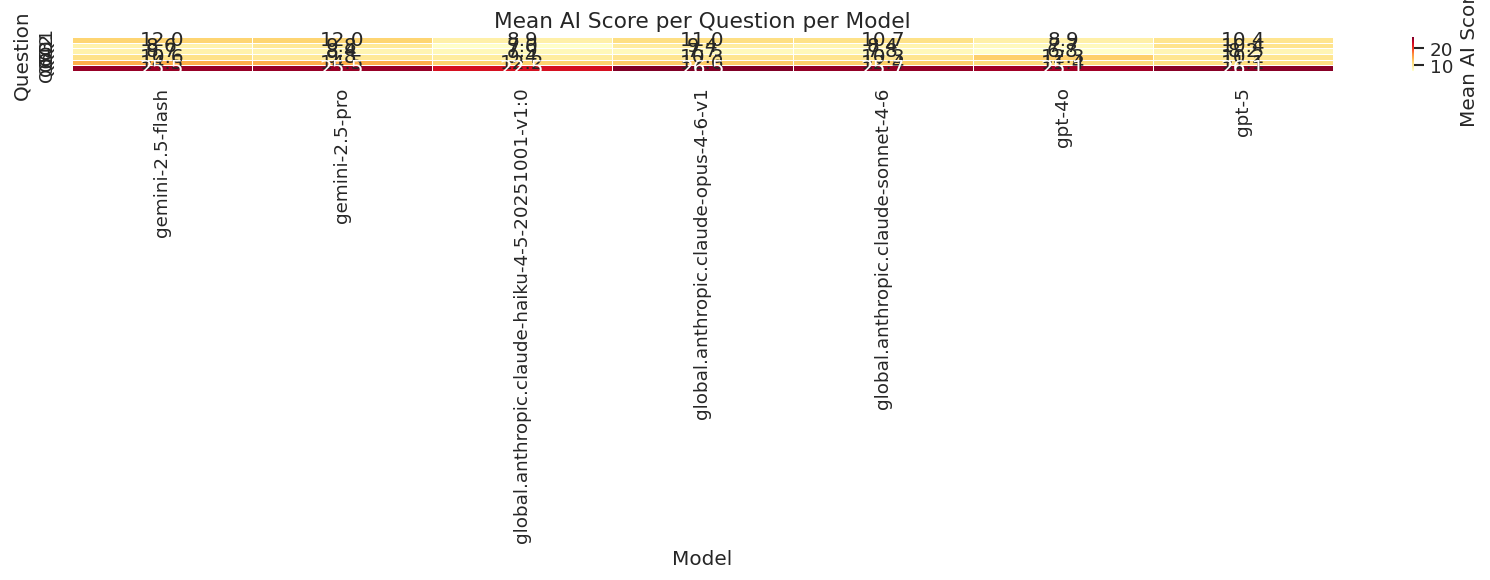

In [13]:
# 5f. Per-question heatmap: rows = Q1-Q6, columns = models, values = mean AI score
heatmap_data = {}
for q in QUESTIONS:
    col = f"q{q}_ai_score"
    heatmap_data[f"Q{q}"] = df.groupby("model")[col].mean()
heatmap_df = pd.DataFrame(heatmap_data).T  # shape: (6 questions, n_models)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean AI Score"})
ax.set_title("Mean AI Score per Question per Model", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Question")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/heatmap_per_question_model.png", bbox_inches="tight")
plt.show()

## Phase 6 — Correlation Analysis & Multicollinearity

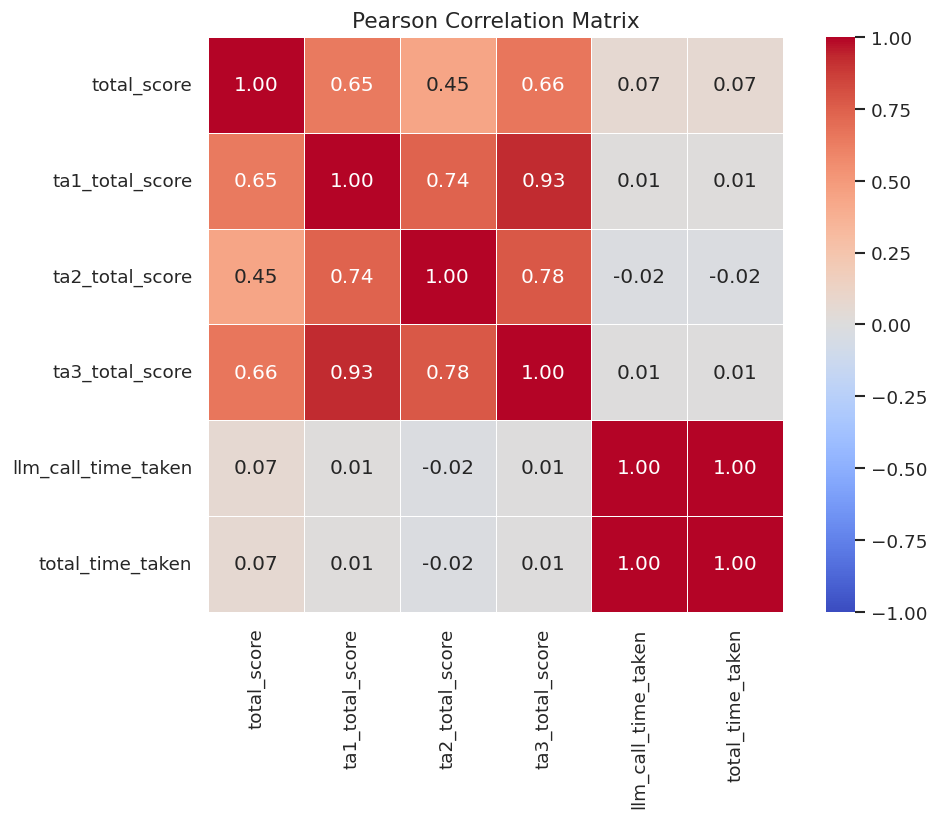


Correlation of total_score with other numeric columns:
ta3_total_score        0.661
ta1_total_score        0.646
ta2_total_score        0.445
llm_call_time_taken    0.070
total_time_taken       0.070
Name: total_score, dtype: float64


In [14]:
# Pearson correlation matrix (exclude constant total_points)
corr_cols = ["total_score", "ta1_total_score", "ta2_total_score", "ta3_total_score",
             "llm_call_time_taken", "total_time_taken"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Pearson Correlation Matrix", fontsize=13)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/corr_heatmap.png", bbox_inches="tight")
plt.show()

print("\nCorrelation of total_score with other numeric columns:")
print(corr_matrix["total_score"].drop("total_score").sort_values(ascending=False).round(3))

In [15]:
# VIF analysis
vif_input = df[corr_cols].dropna()
vif_results = []
for i, col in enumerate(corr_cols):
    vif_val = variance_inflation_factor(vif_input.values, i)
    vif_results.append({"Feature": col, "VIF": round(vif_val, 3)})
vif_df = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)
display(vif_df)
high_vif = vif_df[vif_df["VIF"] > 5]
if not high_vif.empty:
    print(f"\n⚠ Features with VIF > 5 (potential multicollinearity): {high_vif['Feature'].tolist()}")
else:
    print("\n✓ No features with VIF > 5")

,Feature,VIF
5,total_time_taken,2.509320e+09
4,llm_call_time_taken,2.509211e+09
3,ta3_total_score,1.544160e+02
1,ta1_total_score,1.462140e+02
2,ta2_total_score,4.503900e+01
0,total_score,2.157100e+01



⚠ Features with VIF > 5 (potential multicollinearity): ['total_time_taken', 'llm_call_time_taken', 'ta3_total_score', 'ta1_total_score', 'ta2_total_score', 'total_score']


## Phase 7 — Time-Series Checks
> **N/A** — No datetime column present in `grading_results_with_ta.csv`. This phase is skipped.

## Phase 8 — Outlier & Anomaly Detection

In [16]:
# 8a. IQR rule — flag rows per numeric column
outlier_flags = pd.DataFrame(index=df.index)
iqr_cols = ["total_score", "ta1_total_score", "ta2_total_score", "ta3_total_score",
            "llm_call_time_taken", "total_time_taken"]

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_flags[f"{col}_iqr"] = ~df[col].between(lo, hi)
    n_out = outlier_flags[f"{col}_iqr"].sum()
    if n_out > 0:
        print(f"{col}: {n_out} IQR outliers  [lo={lo:.1f}, hi={hi:.1f}]")

# 8b. Z-score rule (|z| > 3)
print("\nZ-score outliers (|z| > 3):")
for col in iqr_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_z = (z > 3).sum()
    if n_z > 0:
        print(f"  {col}: {n_z} rows")

total_score: 1 IQR outliers  [lo=7.0, hi=144.0]
ta1_total_score: 21 IQR outliers  [lo=42.1, hi=127.1]
ta3_total_score: 42 IQR outliers  [lo=38.0, hi=128.0]
llm_call_time_taken: 109 IQR outliers  [lo=-22.0, hi=103.8]
total_time_taken: 109 IQR outliers  [lo=-22.0, hi=103.8]

Z-score outliers (|z| > 3):
  llm_call_time_taken: 13 rows
  total_time_taken: 13 rows


In [17]:
# 8c. LocalOutlierFactor — multivariate anomaly detection
lof_input = df[iqr_cols].dropna()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(lof_input)  # -1 = outlier, 1 = inlier
lof_scores = -lof.negative_outlier_factor_

lof_result = lof_input.copy()
lof_result["lof_label"] = lof_labels
lof_result["lof_score"] = lof_scores.round(3)

n_lof = (lof_labels == -1).sum()
print(f"LOF flagged {n_lof} rows as anomalies (contamination=5%)")

# Merge back to identify which (student_id, model, run)
anomaly_indices = lof_result[lof_result["lof_label"] == -1].index
anomaly_rows = df.loc[anomaly_indices, ["student_id", "model", "run"] + iqr_cols].copy()
anomaly_rows["lof_score"] = lof_result.loc[anomaly_indices, "lof_score"].values
print("\nTop 10 LOF anomalies:")
display(anomaly_rows.sort_values("lof_score", ascending=False).head(10))

LOF flagged 42 rows as anomalies (contamination=5%)

Top 10 LOF anomalies:


,student_id,model,run,total_score,ta1_total_score,ta2_total_score,ta3_total_score,llm_call_time_taken,total_time_taken,lof_score
442,29,gpt-5,2,117.0,96.0,73.0,99.0,386.258571,386.259942,4.485
546,33,gpt-5,1,89.0,88.0,57.0,95.0,285.783349,285.785053,2.492
651,38,gpt-5,1,58.0,65.0,36.0,52.0,281.932794,281.934044,2.426
147,16,gpt-5,1,60.0,84.0,50.0,89.0,262.778862,262.780200,2.050
59,11,gemini-2.5-flash,3,100.0,86.0,57.0,67.0,22.507134,22.509028,1.491
632,37,gpt-5,3,99.5,76.0,44.0,81.0,227.041592,227.042696,1.455
345,24,global.anthropic.claude-sonnet-4-6,1,94.0,107.0,76.0,110.0,80.568035,80.570020,1.439
719,40,gpt-4o,3,123.0,84.0,47.0,86.0,7.244346,7.245601,1.397
66,12,gpt-4o,1,19.5,76.0,72.0,78.0,16.837674,16.838991,1.389
458,29,gemini-2.5-flash,3,122.5,96.0,73.0,99.0,19.780763,19.782712,1.359


## Phase 9 — Data Quality & Cleaning

In [18]:
df_clean = df.copy()

# 9a. Fill missing overall_feedback
n_before = df_clean["overall_feedback"].isna().sum()
df_clean["overall_feedback"] = df_clean["overall_feedback"].fillna("")
print(f"Filled {n_before} missing overall_feedback values with empty string.")

# 9b. Strip whitespace from string columns
str_cols = df_clean.select_dtypes(include="object").columns
for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()
print(f"Stripped whitespace from: {list(str_cols)}")

# 9c. Range check: total_score > total_points
out_of_range = df_clean[df_clean["total_score"] > df_clean["total_points"]]
print(f"\ntotal_score > total_points: {len(out_of_range)} rows")
if len(out_of_range) > 0:
    display(out_of_range[["student_id", "model", "run", "total_score", "total_points"]])

# 9d. Panel completeness: every student × model × run should be present
all_models = df_clean["model"].unique()
all_runs = sorted(df_clean["run"].unique())
all_students = df_clean["student_id"].unique()
full_index = pd.MultiIndex.from_product([all_students, all_models, all_runs],
                                         names=["student_id", "model", "run"])
existing_index = pd.MultiIndex.from_frame(df_clean[["student_id", "model", "run"]])
missing_combos = full_index.difference(existing_index)
print(f"\nMissing (student_id, model, run) combos: {len(missing_combos)}")
if len(missing_combos) > 0 and len(missing_combos) <= 20:
    print(missing_combos.to_frame(index=False))

# 9e. Remove helper flag columns
df_clean.drop(columns=["feedback_missing"], errors="ignore", inplace=True)

print("\nCleaned dataframe shape:", df_clean.shape)

Filled 22 missing overall_feedback values with empty string.
Stripped whitespace from: ['model', 'feedback_by_question', 'overall_feedback', 'ta_grades_by_question', 'feedback_parsed', 'ta_grades_parsed', 'q6_ta2_score']

total_score > total_points: 0 rows

Missing (student_id, model, run) combos: 0

Cleaned dataframe shape: (840, 45)


## Phase 10 — Feature Engineering

In [19]:
# 10a. Aggregate TA scores
df_clean["ta_score_avg"] = df_clean[["ta1_total_score", "ta2_total_score", "ta3_total_score"]].mean(axis=1)
df_clean["ta_score_sum"] = df_clean[["ta1_total_score", "ta2_total_score", "ta3_total_score"]].sum(axis=1)

# 10b. AI divergence from TA consensus
df_clean["score_diff"] = df_clean["total_score"] - df_clean["ta_score_avg"]

# 10c. Normalized scores (0-1)
df_clean["normalized_ai_score"] = df_clean["total_score"] / df_clean["total_points"]

# 10d. Model vendor grouping
def get_vendor(model_name: str) -> str:
    m = model_name.lower()
    if "gpt" in m or "openai" in m:
        return "OpenAI"
    elif "claude" in m or "anthropic" in m:
        return "Anthropic"
    elif "gemini" in m or "google" in m:
        return "Google"
    elif "llama" in m or "meta" in m:
        return "Meta"
    else:
        return "Other"

df_clean["model_vendor"] = df_clean["model"].apply(get_vendor)
print("Vendor distribution:")
display(df_clean["model_vendor"].value_counts())

# 10e. Feedback length
df_clean["feedback_length"] = df_clean["overall_feedback"].str.len()

# 10f. Run averages per (student_id, model)
run_stats = df_clean.groupby(["student_id", "model"])["total_score"].agg(
    run_mean_score="mean", run_score_std="std"
).reset_index()
df_clean = df_clean.merge(run_stats, on=["student_id", "model"], how="left")

print("\nNew feature preview:")
display(df_clean[["student_id", "model", "run", "total_score", "ta_score_avg",
                   "score_diff", "normalized_ai_score", "feedback_length",
                   "model_vendor", "run_mean_score", "run_score_std"]].head(6))

Vendor distribution:


model_vendor
Anthropic    360
OpenAI       240
Google       240
Name: count, dtype: int64


New feature preview:


,student_id,model,run,total_score,ta_score_avg,score_diff,normalized_ai_score,feedback_length,model_vendor,run_mean_score,run_score_std
0,1,gpt-5,1,80.5,79.666667,0.833333,0.605263,535,OpenAI,86.333333,6.006940
1,1,gpt-5,2,86.0,79.666667,6.333333,0.646617,411,OpenAI,86.333333,6.006940
2,1,gpt-5,3,92.5,79.666667,12.833333,0.695489,466,OpenAI,86.333333,6.006940
3,1,gpt-4o,1,87.0,79.666667,7.333333,0.654135,267,OpenAI,85.000000,2.645751
4,1,gpt-4o,2,82.0,79.666667,2.333333,0.616541,218,OpenAI,85.000000,2.645751
5,1,gpt-4o,3,86.0,79.666667,6.333333,0.646617,263,OpenAI,85.000000,2.645751


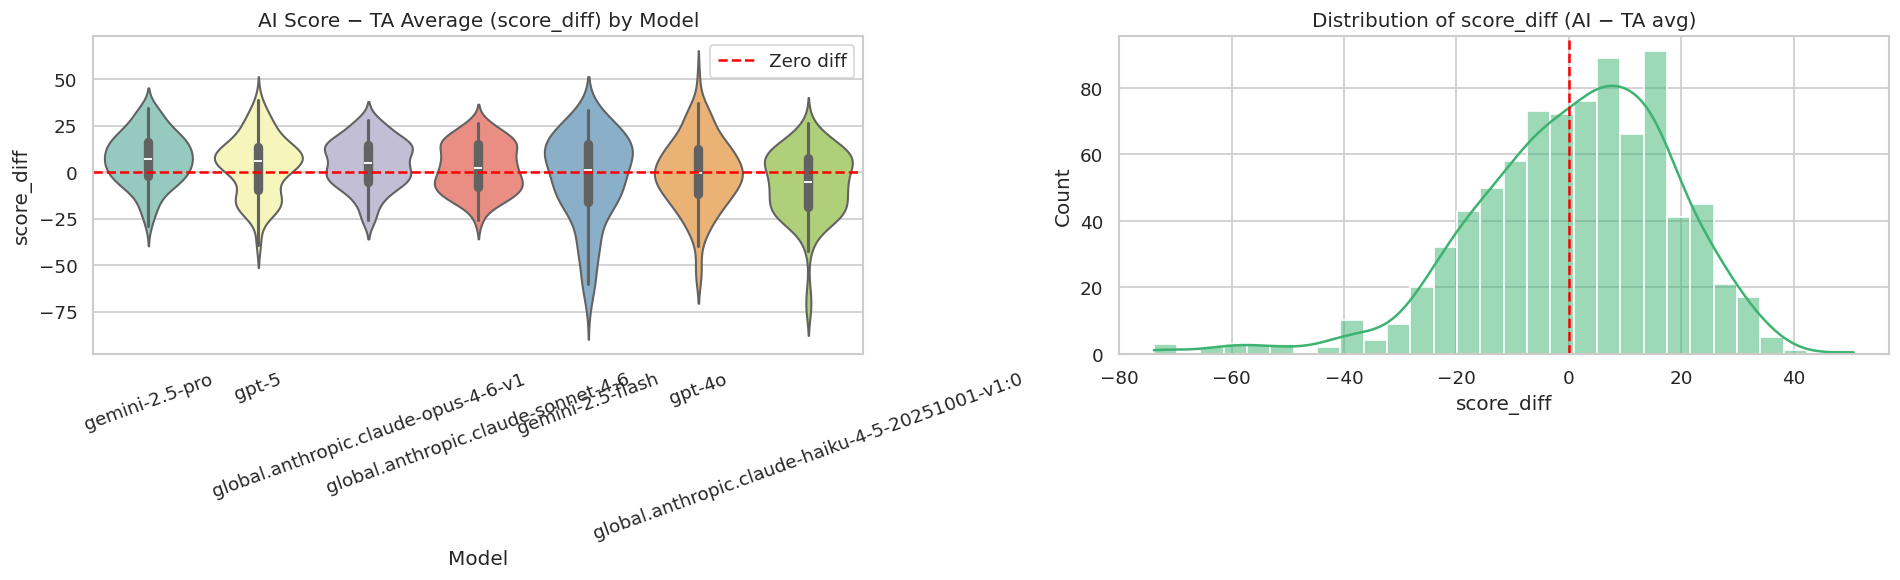


score_diff summary:
count    840.000
mean       0.967
std       17.597
min      -73.833
25%       -9.667
50%        2.667
75%       13.708
max       50.667
Name: score_diff, dtype: float64


In [20]:
# 10g. score_diff visualization by model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin: score_diff by model
score_diff_order = df_clean.groupby("model")["score_diff"].median().sort_values(ascending=False).index
sns.violinplot(data=df_clean, x="model", y="score_diff", order=score_diff_order,
               ax=axes[0], palette="Set3", inner="box")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero diff")
axes[0].set_title("AI Score − TA Average (score_diff) by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("score_diff")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

# Hist: score_diff overall
sns.histplot(df_clean["score_diff"], bins=30, kde=True, ax=axes[1], color="mediumseagreen")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution of score_diff (AI − TA avg)")
axes[1].set_xlabel("score_diff")

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/score_diff_analysis.png", bbox_inches="tight")
plt.show()

print(f"\nscore_diff summary:\n{df_clean['score_diff'].describe().round(3)}")

## Deliverables — Save Outputs

In [21]:
# Save cleaned sample (first 50 rows) with engineered features
output_cols = [
    "student_id", "model", "run", "total_score", "total_points",
    "ta1_total_score", "ta2_total_score", "ta3_total_score",
    "ta_score_avg", "score_diff", "normalized_ai_score",
    "model_vendor", "feedback_length", "run_mean_score", "run_score_std",
    "llm_call_time_taken", "total_time_taken",
    "overall_feedback",
] + ai_q_cols

sample_df = df_clean[[c for c in output_cols if c in df_clean.columns]].head(50)
sample_path = f"{OUTPUT_DIR}/cleaned_sample.csv"
sample_df.to_csv(sample_path, index=False)
print(f"Saved cleaned sample ({len(sample_df)} rows × {sample_df.shape[1]} cols) → {sample_path}")

# List all output files
import glob
output_files = sorted(glob.glob(f"{OUTPUT_DIR}/*"))
print("\nOutput files:")
for f in output_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Saved cleaned sample (50 rows × 24 cols) → outputs/cleaned_sample.csv

Output files:
  outputs/bar_model_comparison.png  (86.6 KB)
  outputs/boxplot_score_by_model.png  (68.9 KB)
  outputs/boxplots_numeric.png  (85.2 KB)
  outputs/cleaned_sample.csv  (35.9 KB)
  outputs/corr_heatmap.png  (76.7 KB)
  outputs/heatmap_per_question_model.png  (73.1 KB)
  outputs/hist_numeric.png  (132.2 KB)
  outputs/scatter_ai_vs_ta.png  (270.9 KB)
  outputs/score_diff_analysis.png  (141.6 KB)
